In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense


### Load Dataset

In [58]:
df = pd.read_csv(r"C:\Users\admin\Downloads\equipment_sensors.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df.head()


,temp,vibration,rpm,pressure
timestamp,,,,
2024-01-01 00:00:00,62.483571,12.798711,1466.241086,280.921924
2024-01-01 00:01:00,59.308678,11.849267,1492.774066,291.396150
2024-01-01 00:02:00,63.238443,10.119261,1460.379004,295.863945
2024-01-01 00:03:00,67.615149,8.706126,1484.601924,318.876877
2024-01-01 00:04:00,58.829233,11.396447,1405.319267,305.565531


### Data Cleaning

In [59]:
print(df.isnull().sum())

df = df.fillna(method='ffill')
df = df.drop_duplicates()
def remove_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[~((data < lower) | (data > upper)).any(axis=1)]

df_clean = remove_outliers_iqr(df)

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)
df = df_clean


temp         0
vibration    0
rpm          0
pressure     0
dtype: int64
Original shape: (1000, 4)
After outlier removal: (969, 4)


C:\Users\admin\AppData\Local\Temp\ipykernel_13988\1124529058.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [60]:
from tsfresh import extract_features

# Reset index
ts_df = df.reset_index()

# Convert timestamp to numeric order
ts_df['time'] = range(len(ts_df))

# Convert to long format
long_df = pd.melt(
    ts_df,
    id_vars=["time"],
    value_vars=["temp","vibration","rpm","pressure"],
    var_name="sensor",
    value_name="value"
)

# Add id column (single machine)
long_df['id'] = 1

# Extract tsfresh features
tsfresh_features = extract_features(
    long_df,
    column_id="id",
    column_sort="time",
    column_kind="sensor",
    column_value="value"
)

tsfresh_features.head()


Feature Extraction: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.46s/it]


,temp__variance_larger_than_standard_deviation,temp__has_duplicate_max,temp__has_duplicate_min,temp__has_duplicate,temp__sum_values,temp__abs_energy,temp__mean_abs_change,temp__mean_change,temp__mean_second_derivative_central,temp__median,...,pressure__fourier_entropy__bins_5,pressure__fourier_entropy__bins_10,pressure__fourier_entropy__bins_100,pressure__permutation_entropy__dimension_3__tau_1,pressure__permutation_entropy__dimension_4__tau_1,pressure__permutation_entropy__dimension_5__tau_1,pressure__permutation_entropy__dimension_6__tau_1,pressure__permutation_entropy__dimension_7__tau_1,pressure__query_similarity_count__query_None__threshold_0.0,pressure__mean_n_absolute_max__number_of_maxima_7
1,1.0,0.0,0.0,0.0,58265.877915,3.525496e+06,5.425961,0.000392,0.004599,60.148781,...,1.295086,1.963985,3.935335,1.790266,3.164901,4.716725,6.135843,6.729682,NaN,323.546327


### Visualization

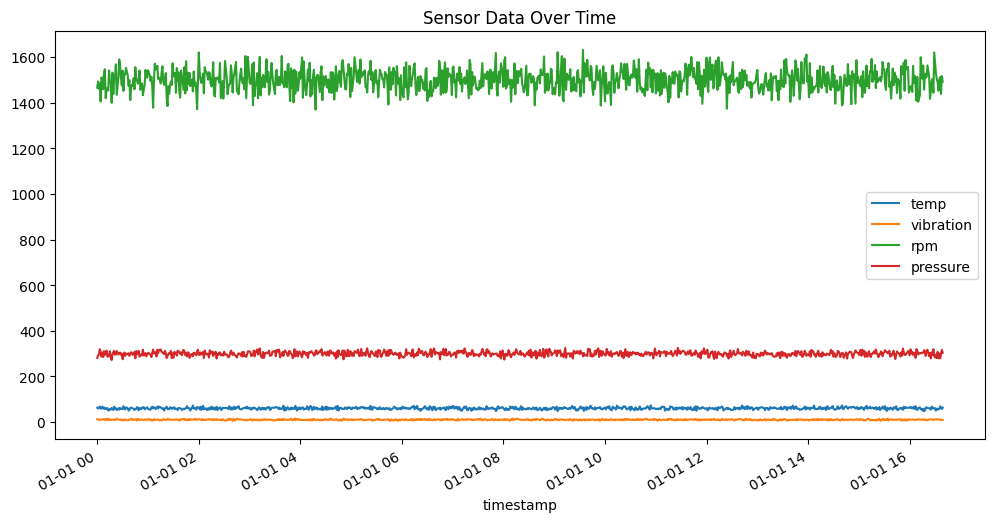

In [61]:
df.plot(figsize=(12,6))
plt.title("Sensor Data Over Time")
plt.show()


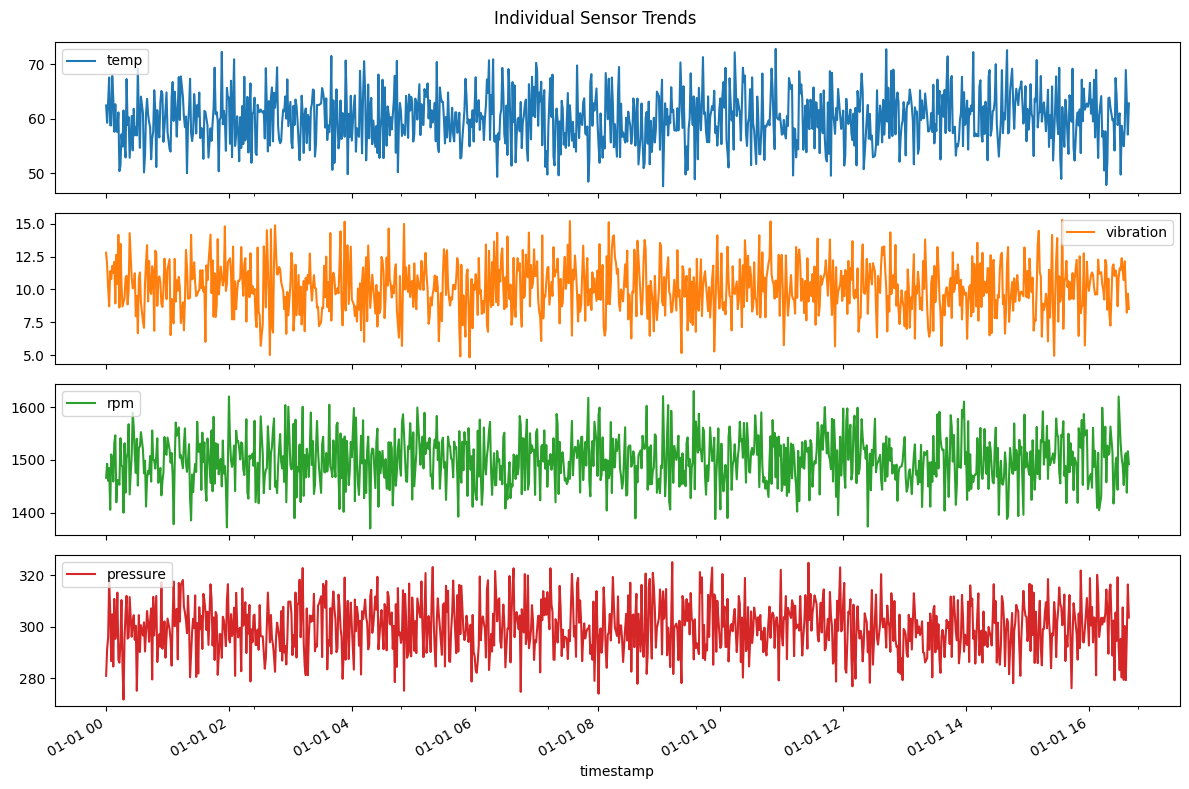

In [62]:
df[['temp','vibration','rpm','pressure']].plot(subplots=True, figsize=(12,8), title="Individual Sensor Trends")
plt.tight_layout()
plt.show()


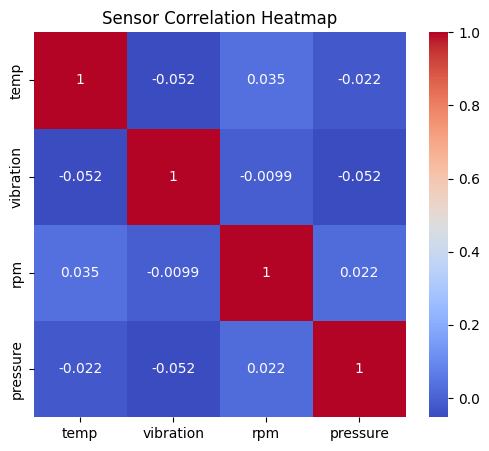

In [63]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Sensor Correlation Heatmap")
plt.show()


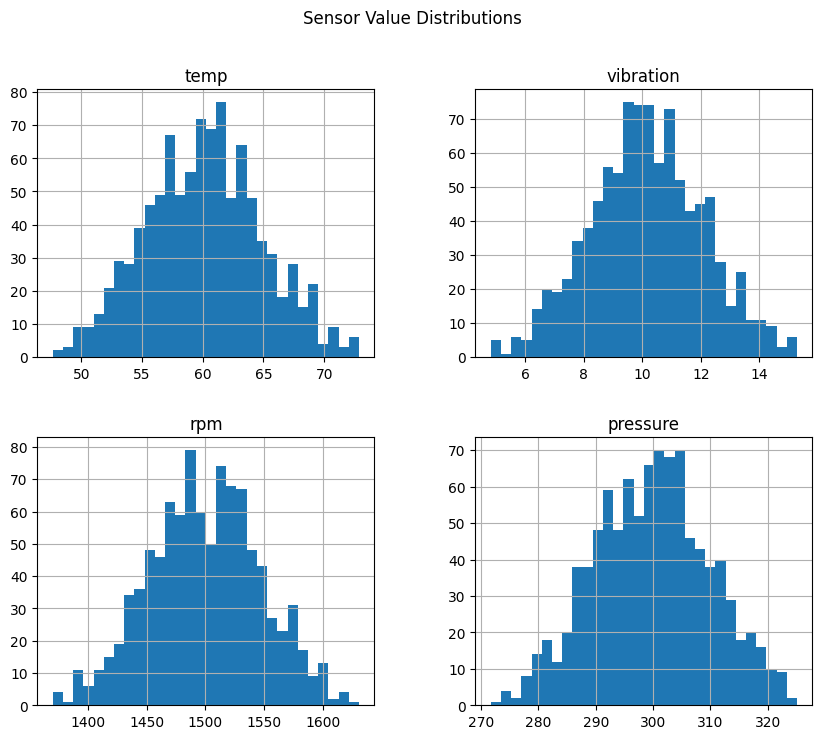

In [64]:
df.hist(figsize=(10,8), bins=30)
plt.suptitle("Sensor Value Distributions")
plt.show()


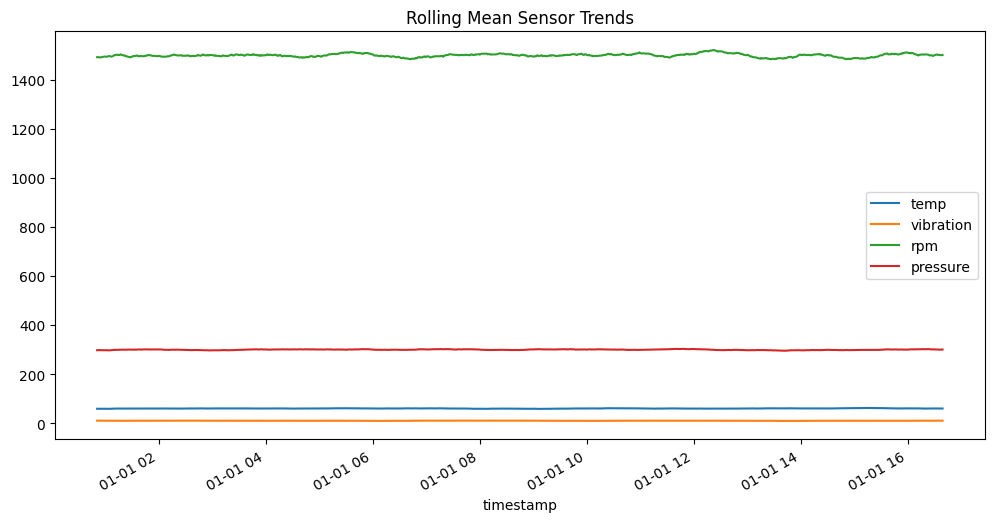

In [65]:
rolling = df.rolling(window=50).mean()
rolling.plot(figsize=(12,6))
plt.title("Rolling Mean Sensor Trends")
plt.show()


### Normalization

In [66]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)


### ISOLATION FOREST MODEL

### Isolation Forest

In [67]:
iso_model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_iforest'] = iso_model.fit_predict(scaled_data)

df['anomaly_iforest'] = df['anomaly_iforest'].map({1:0, -1:1})


### Isolation Forest Visualization

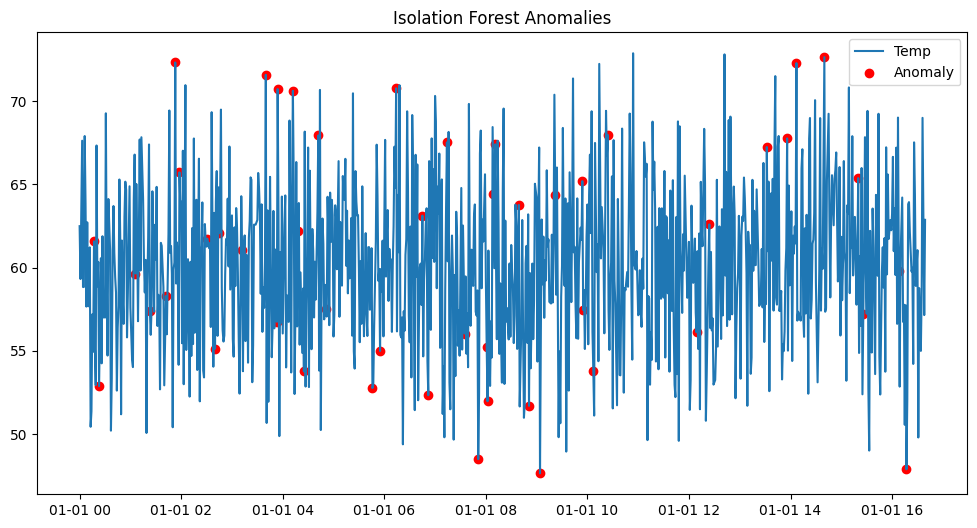

In [68]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['temp'], label='Temp')
plt.scatter(df[df['anomaly_iforest']==1].index,
            df[df['anomaly_iforest']==1]['temp'],
            color='red', label='Anomaly')
plt.legend()
plt.title("Isolation Forest Anomalies")
plt.show()


### LSTM AUTOENCODER

### Sequence Creation

In [69]:
def create_sequences(data, seq_len):
    X = []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
    return np.array(X)

seq_len = 30
X = create_sequences(scaled_data, seq_len)


### Build LSTM Autoencoder

In [70]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_len, X.shape[2]), return_sequences=False),
    RepeatVector(seq_len),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(X.shape[2]))
])

model.compile(optimizer='adam', loss='mse')
model.summary()


C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 64)                  │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector_2 (RepeatVector)       │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 30, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 30, 4)               │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,948 (199.02 KB)

 Trainable params: 50,948 (199.02 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [71]:
model.fit(X, X, epochs=10, batch_size=32, validation_split=0.1)


Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.1273 - val_loss: 0.0531
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0474 - val_loss: 0.0446
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0415 - val_loss: 0.0400
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0376 - val_loss: 0.0370
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0351 - val_loss: 0.0354
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0343 - val_loss: 0.0352
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0341 - val_loss: 0.0351
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0341 - val_loss: 0.0351
Epoch 9/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0340 - val_loss: 0.0351
Epoch 10/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0340 - val_loss: 0.0349


### Reconstruction Error

In [72]:
X_pred = model.predict(X)
mse = np.mean(np.power(X - X_pred, 2), axis=(1,2))

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step


### Threshold Selection

In [73]:
threshold = np.percentile(mse, 95)
threshold


0.04024335563363852

### LSTM Anomaly Detection

In [74]:
lstm_anomalies = mse > threshold


### Add Final Anomaly Column

In [75]:
df['anomaly_lstm'] = 0
df.iloc[seq_len:, df.columns.get_loc("anomaly_lstm")] = lstm_anomalies.astype(int)


### Visualization

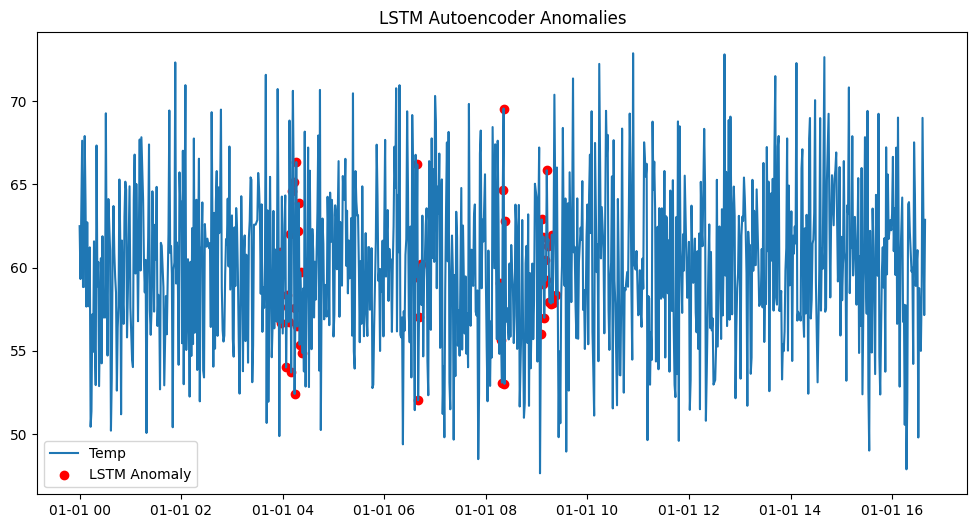

In [76]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['temp'], label="Temp")
plt.scatter(df[df['anomaly_lstm']==1].index,
            df[df['anomaly_lstm']==1]['temp'],
            color='red', label="LSTM Anomaly")
plt.legend()
plt.title("LSTM Autoencoder Anomalies")
plt.show()


### FINAL OUTPUT DATA

In [77]:
df.head(20)


,temp,vibration,rpm,pressure,anomaly_iforest,anomaly_lstm
timestamp,,,,,,
2024-01-01 00:00:00,62.483571,12.798711,1466.241086,280.921924,0,0
2024-01-01 00:01:00,59.308678,11.849267,1492.774066,291.396150,0,0
2024-01-01 00:02:00,63.238443,10.119261,1460.379004,295.863945,0,0
2024-01-01 00:03:00,67.615149,8.706126,1484.601924,318.876877,0,0
2024-01-01 00:04:00,58.829233,11.396447,1405.319267,305.565531,0,0
2024-01-01 00:05:00,58.829315,10.786971,1510.664685,286.645184,0,0
2024-01-01 00:06:00,67.896064,11.790386,1500.060274,304.860363,0,0
2024-01-01 00:07:00,63.837174,11.270344,1459.145568,284.526960,0,0
2024-01-01 00:08:00,57.652628,12.099105,1532.962283,310.826911,0,0


### SUMMARY METRICS

In [78]:
print("Isolation Forest Anomalies:", df['anomaly_iforest'].sum())
print("LSTM Anomalies:", df['anomaly_lstm'].sum())


Isolation Forest Anomalies: 49
LSTM Anomalies: 47


In [79]:
total = len(df)
iforest_anom = df['anomaly_iforest'].sum()
lstm_anom = df['anomaly_lstm'].sum()

print("Total Records:", total)
print("Isolation Forest Anomalies:", iforest_anom, "(", round(iforest_anom/total*100,2), "% )")
print("LSTM Anomalies:", lstm_anom, "(", round(lstm_anom/total*100,2), "% )")


Total Records: 969
Isolation Forest Anomalies: 49 ( 5.06 % )
LSTM Anomalies: 47 ( 4.85 % )


In [80]:
summary = pd.DataFrame({
    "Model": ["Isolation Forest", "LSTM Autoencoder"],
    "Anomalies Detected": [iforest_anom, lstm_anom],
    "Percentage (%)": [
        round(iforest_anom/total*100,2),
        round(lstm_anom/total*100,2)
    ]
})

summary


,Model,Anomalies Detected,Percentage (%)
0,Isolation Forest,49,5.06
1,LSTM Autoencoder,47,4.85


In [81]:
df.to_csv("final_anomaly_output.csv")
